# Model-based bootstraps: residual and sieve

Block bootstraps keep dependence by resampling contiguous chunks of the observed
series. Model-based bootstraps work differently. They fit one parametric
model to the data, then regenerate each replicate recursively from the fitted
dynamics driven by resampled, centered innovations:

`x*[t] = c + sum_j phi_j x*[t-j] + e*[t]`

Nothing is resampled at the level of observations. A replicate is a new path
simulated forward through the estimated dynamics, so there are no observation
indices and no out-of-bag set. There are three model-based specs in tsbootstrap to
work through:

1. `ResidualBootstrap(model=AR(order=...))` on a synthetic AR(2).
2. `ResidualBootstrap(model=ARIMA(order=(p, d, q)))` on a near-unit-root real
   series that needs differencing.
3. `SieveAR`, which picks the AR order from the data before resampling.

We close on the stability guard: what tsbootstrap does when the fitted model is
explosive or sits on a unit root. The code runs offline against bundled datasets.

In [1]:
# On Colab or Binder, install tsbootstrap first (skipped if already present):
try:
    import tsbootstrap  # noqa: F401
except ImportError:
    %pip install -q "tsbootstrap[examples]"

# The ARIMA and sieve paths use statsmodels, which ships in the [examples] extra
# (it pulls in tsbootstrap[models]). The bundled datasets come from sktime and
# statsmodels, both also in [examples].

## A synthetic AR(2)

We start with a stationary AR(2) so the dependence structure is known exactly:
`x[t] = 0.5 x[t-1] + 0.3 x[t-2] + e[t]`. The two coefficients sum to 0.8, well
inside the stationary region, so the fitted model will be stable.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from tsbootstrap import bootstrap, ResidualBootstrap, SieveAR, AR, ARIMA

rng = np.random.default_rng(0)
n = 300
phi1, phi2 = 0.5, 0.3
x = np.zeros(n)
e = rng.standard_normal(n)
for t in range(2, n):
    x[t] = phi1 * x[t - 1] + phi2 * x[t - 2] + e[t]
x[:5]

array([ 0.        ,  0.        ,  0.64042265,  0.42511144, -0.13098686])

## ResidualBootstrap with a fixed-order AR

`ResidualBootstrap(model=AR(order=2))` fits an AR(2) once by ordinary least
squares, centers its residuals, and then simulates each replicate forward. The
innovation resampler defaults to `IID()`: the centered residuals are drawn with
replacement, independently, and fed through the fitted recursion. The result has
the same `(n_bootstraps, n)` shape as a block bootstrap, but every row is a fresh
simulated path rather than a reshuffling of the original points.

In [3]:
res_ar = bootstrap(
    x, method=ResidualBootstrap(model=AR(order=2)), n_bootstraps=200, random_state=1
)
samples_ar = res_ar.values()
samples_ar.shape  # (n_bootstraps, n)

(200, 300)

### No observation indices, no out-of-bag

This is the structural difference from block and IID methods. Because a recursive
replicate is simulated rather than resampled, there is no mapping back to original
observation positions. `indices()` returns `None`, and asking for the out-of-bag
mask raises rather than inventing one. The EnbPI uncertainty layer, which is built
on the out-of-bag structure, therefore cannot consume a recursive method.

In [4]:
from tsbootstrap.errors import OOBUnavailableError

print("indices():", res_ar.indices())  # None for a recursive method

try:
    res_ar.get_oob_mask()
except OOBUnavailableError as exc:
    print("get_oob_mask() raised:", type(exc).__name__)
    print(str(exc).splitlines()[0])

indices(): None
get_oob_mask() raised: OOBUnavailableError
[TSB_OOB_UNAVAILABLE] in-bag/out-of-bag counts require observation indices, which method 'residual' does not produce Hint: Use an observation-resampling method (IID or a block method) for OOB.


### Replicate paths

Each replicate is a new realisation of the same fitted AR(2) dynamics. They share
the persistence and variance of the original but are not reshufflings of it: the
recursion can wander anywhere the model allows.

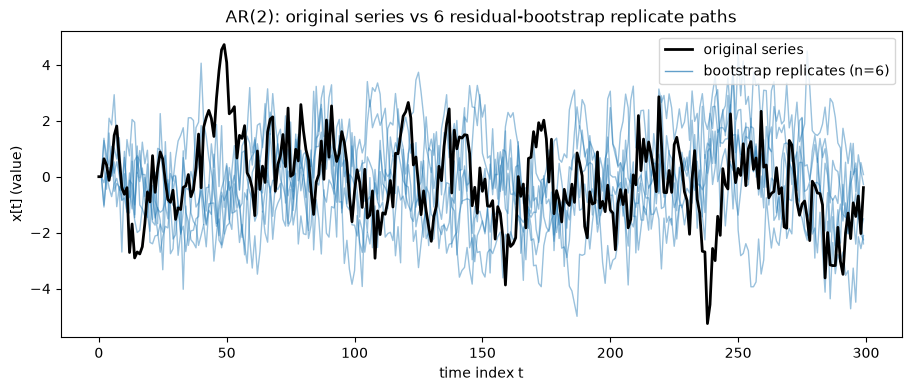

In [5]:
from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(9, 3.8), layout="constrained")
for i in range(6):
    ax.plot(samples_ar[i], color="tab:blue", alpha=0.45, lw=1.0)
ax.plot(x, color="black", lw=2.0, label="original series")
# Proxy handle so the replicate cloud gets one legend entry rather than six.
replicate_handle = Line2D([], [], color="tab:blue", alpha=0.7, lw=1.0)
ax.set_title("AR(2): original series vs 6 residual-bootstrap replicate paths")
ax.set_xlabel("time index t")
ax.set_ylabel("x[t] (value)")
ax.legend(
    handles=[ax.lines[-1], replicate_handle],
    labels=["original series", "bootstrap replicates (n=6)"],
    loc="upper right",
)
plt.show()

A quick sanity check that the resampling is innovation-based. The original
series and the replicates have comparable lag-1 autocorrelation, because every
replicate is driven through the same fitted recursion. Plain IID resampling of the
observations would instead collapse that autocorrelation toward zero.

In [6]:
import pandas as pd


def lag1_acf(series):
    s = np.asarray(series, dtype=float)
    s = s - s.mean()
    return float(np.dot(s[:-1], s[1:]) / np.dot(s, s))


rep_acf = np.array([lag1_acf(v) for v in samples_ar])
acf_table = pd.DataFrame(
    {"lag-1 ACF": [lag1_acf(x), rep_acf.mean()]},
    index=["original series", "replicate mean (n=200)"],
)
acf_table.round(3)

,lag-1 ACF
original series,0.72
replicate mean (n=200),0.70


## ResidualBootstrap with ARIMA on a near-unit-root series

A pure AR cannot represent a series with a stochastic trend. The Nile river annual
flow (statsmodels' bundled `nile` dataset, 100 yearly observations) drifts like a
near-unit-root process: its level wanders rather than reverting to a fixed mean.
The integrated `ARIMA(order=(p, d, q))` model handles this by differencing `d`
times before fitting an ARMA to the stationary differenced series, then
integrating each simulated path back up to the level.

ARIMA needs the MA / maximum-likelihood machinery in statsmodels, which is the
`[models]` extra (included in `[examples]`). AR, VAR, and the sieve are fit by
direct OLS and need no optional dependency.

In [7]:
import statsmodels.api as sm

nile = sm.datasets.nile.load_pandas().data["volume"].to_numpy(dtype=float)
print("nile length:", nile.shape[0])

res_arima = bootstrap(
    nile,
    method=ResidualBootstrap(model=ARIMA(order=(1, 1, 1))),
    n_bootstraps=200,
    random_state=2,
)
samples_arima = res_arima.values()
print("ARIMA replicate shape:", samples_arima.shape)
print("run failed:", res_arima.metadata.failed)
print("indices():", res_arima.indices())  # still None: ARIMA is recursive too

nile length: 100
ARIMA replicate shape: (200, 100)
run failed: False
indices(): None


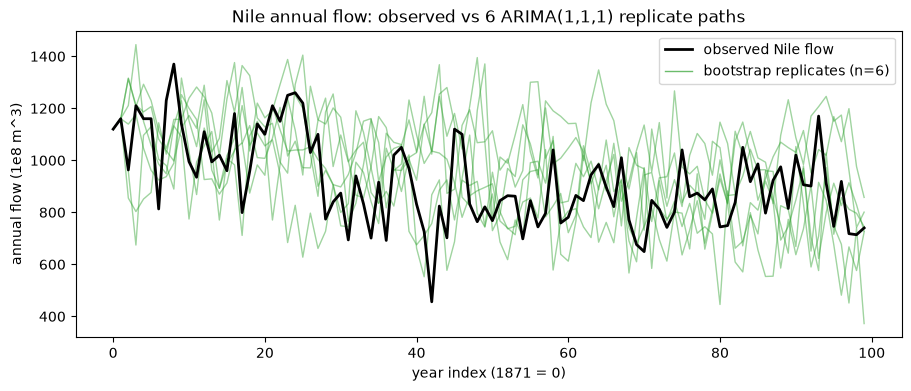

In [8]:
fig, ax = plt.subplots(figsize=(9, 3.8), layout="constrained")
for i in range(6):
    ax.plot(samples_arima[i], color="tab:green", alpha=0.45, lw=1.0)
ax.plot(nile, color="black", lw=2.0, label="Nile flow")
replicate_handle = Line2D([], [], color="tab:green", alpha=0.7, lw=1.0)
ax.set_title("Nile annual flow: observed vs 6 ARIMA(1,1,1) replicate paths")
ax.set_xlabel("year index (1871 = 0)")
ax.set_ylabel("annual flow (1e8 m^3)")
ax.legend(
    handles=[ax.lines[-1], replicate_handle],
    labels=["observed Nile flow", "bootstrap replicates (n=6)"],
    loc="upper right",
)
plt.show()

The replicates condition on the observed initial differenced state, so they
start at the right level and then diverge as the resampled innovations propagate.
The `d = 1` differencing is what lets a model-based bootstrap follow a wandering
level that a stationary AR could not.

## SieveAR: let the data choose the order

The sieve bootstrap is a residual AR bootstrap that does not ask you to fix the
order. `SieveAR` selects the AR order once from the data by an information
criterion (default `bic`, with `aic` and `hqic` available), bounded by `min_lag`
and `max_lag`, then runs the recursive AR residual bootstrap at that order.

We use the bundled sunspot series (statsmodels' `sunspots`, 309 yearly counts),
which has rich autoregressive structure. The order chosen is the same one
`SieveAR` uses internally; `select_ar_order` is the function the spec calls.

In [9]:
import pandas as pd
from tsbootstrap.model.fit import select_ar_order

sun = sm.datasets.sunspots.load_pandas().data["SUNACTIVITY"].to_numpy(dtype=float)
print("sunspots length:", sun.shape[0])

order_table = pd.DataFrame(
    {
        "criterion": ["bic", "aic", "hqic"],
        "selected_AR_order": [
            select_ar_order(sun, criterion="bic"),
            select_ar_order(sun, criterion="aic"),
            select_ar_order(sun, criterion="hqic"),
        ],
    }
).set_index("criterion")
order_bic = int(order_table.loc["bic", "selected_AR_order"])
order_table

sunspots length: 309


,selected_AR_order
criterion,
bic,9
aic,9
hqic,9


sieve replicate shape: (200, 309)
indices(): None


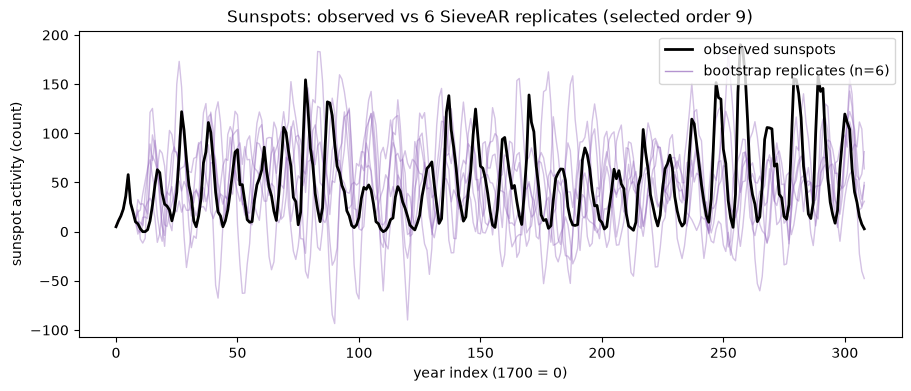

In [10]:
res_sieve = bootstrap(
    sun, method=SieveAR(criterion="bic"), n_bootstraps=200, random_state=3
)
samples_sieve = res_sieve.values()
print("sieve replicate shape:", samples_sieve.shape)
print("indices():", res_sieve.indices())  # recursive: None

fig, ax = plt.subplots(figsize=(9, 3.8), layout="constrained")
for i in range(6):
    ax.plot(samples_sieve[i], color="tab:purple", alpha=0.40, lw=1.0)
ax.plot(sun, color="black", lw=2.0, label="sunspots")
replicate_handle = Line2D([], [], color="tab:purple", alpha=0.7, lw=1.0)
ax.set_title(f"Sunspots: observed vs 6 SieveAR replicates (selected order {order_bic})")
ax.set_xlabel("year index (1700 = 0)")
ax.set_ylabel("sunspot activity (count)")
ax.legend(
    handles=[ax.lines[-1], replicate_handle],
    labels=["observed sunspots", "bootstrap replicates (n=6)"],
    loc="upper right",
)
plt.show()

`SieveAR` defaults `min_lag=1` and leaves `max_lag=None`, which lets the
selector consider up to roughly `10 * log10(n)` lags. Tightening the bounds, for
example `SieveAR(min_lag=1, max_lag=4)`, caps the search and would force a smaller
order here.

## The stability guard

A recursive bootstrap of a non-stationary fitted model produces explosive paths,
so tsbootstrap checks the fitted dynamics before simulating. The check is on the
companion-matrix spectral radius of the fitted AR coefficients:

- radius `>= 1.0`: the model is non-stationary. The behaviour depends on
  `stability_policy` (a field on every model spec, default `"raise"`).
- `0.98 <= radius < 1.0`: near a unit root. The run proceeds but emits a
  `NearUnitRootWarning`.

### Near a unit root: warn, but proceed

A random walk has no mean reversion, so a fitted AR(1) lands just below 1; the
longer the walk, the closer the fitted coefficient sits to 1. The bootstrap runs
and returns replicates, but warns that the paths may be unreliable.

In [11]:
import warnings
from tsbootstrap.errors import NearUnitRootWarning, ModelStabilityError

# A longer random walk pins the fitted AR(1) coefficient into the [0.98, 1.0) band.
rw = np.cumsum(np.random.default_rng(0).standard_normal(600))

with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    res_rw = bootstrap(
        rw, method=ResidualBootstrap(model=AR(order=1)), n_bootstraps=50, random_state=4
    )
near_unit = [w for w in caught if issubclass(w.category, NearUnitRootWarning)]
print("replicates produced:", len(res_rw))
print("run failed:", res_rw.metadata.failed)
print("NearUnitRootWarning emitted:", bool(near_unit))
if near_unit:
    print(str(near_unit[0].message).splitlines()[0])

replicates produced: 50
run failed: False
NearUnitRootWarning emitted: True
[TSB_NEAR_UNIT_ROOT] fitted AR model is near a unit root (companion spectral radius 0.9935); bootstrap paths may be unreliable


### Explosive fit: raise, or skip

For a genuinely explosive process the fitted coefficient exceeds 1 and the
spectral radius crosses the threshold. We build a deterministic explosive series
(`z[t] = 1.05 z[t-1] + small noise`) so the fitted AR(1) is clearly non-stationary.

With the default `stability_policy="raise"`, the run raises `ModelStabilityError`
rather than returning explosive garbage.

In [12]:
explosive = np.empty(200)
explosive[0] = 1.0
for t in range(1, explosive.shape[0]):
    explosive[t] = 1.05 * explosive[t - 1] + 0.01 * rng.standard_normal()

try:
    bootstrap(
        explosive,
        method=ResidualBootstrap(model=AR(order=1)),  # stability_policy="raise" default
        n_bootstraps=10,
        random_state=5,
    )
except ModelStabilityError as exc:
    print("raised:", type(exc).__name__)
    print(str(exc).splitlines()[0])

raised: ModelStabilityError
[TSB_UNSTABLE_MODEL] fitted AR model is non-stationary (companion spectral radius 1.0500 >= 1); a recursive bootstrap would produce explosive paths


Setting `stability_policy="skip"` turns that hard failure into an empty
result instead. The whole run fails as a unit: no replicates are generated, `len(result)`
is 0, and the metadata records the failure with a reason. The run never falls back to
a different method silently. A batch caller can detect the empty result and route
around it.

In [13]:
res_skip = bootstrap(
    explosive,
    method=ResidualBootstrap(model=AR(order=1, stability_policy="skip")),
    n_bootstraps=10,
    random_state=5,
)
print("number of replicates:", len(res_skip))
print("values() shape:", res_skip.values().shape)
print("metadata.failed:", res_skip.metadata.failed)
print("failure_reason:", res_skip.metadata.failure_reason.splitlines()[0])

number of replicates: 0
values() shape: (0,)
metadata.failed: True
failure_reason: [TSB_UNSTABLE_MODEL] fitted AR model is non-stationary (companion spectral radius 1.0500 >= 1); a recursive bootstrap would produce explosive paths


## The three model-based specs at a glance

Model-based bootstraps fit a parametric model once, then regenerate each replicate
recursively from the fitted dynamics and resampled centered innovations:

- `ResidualBootstrap(model=AR(order=p))`: fixed-order AR, fit by OLS, IID
  innovation resampling by default.
- `ResidualBootstrap(model=ARIMA(order=(p, d, q)))`: differences `d` times, fits an
  ARMA (needs statsmodels), integrates each simulated path back to the level. Use it
  for a near-unit-root or trending series.
- `SieveAR`: picks the AR order from the data by an information criterion, then runs
  the recursive AR residual bootstrap.

All three are recursive, so `indices()` is `None` and there is no out-of-bag set,
which is why these methods are not EnbPI-capable. All three also refuse to simulate
from an unstable fit: a near-unit-root model warns, an explosive one either raises
(`stability_policy="raise"`, the default) or returns a flagged empty result
(`stability_policy="skip"`).